In [1]:
import os
import sys
from os import path
sys.path.insert(0, "/home/thomasb")
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
#import sat_utils as su
import importlib
#from albatros_analysis.src.utils import orbcomm_utils as outils
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import sat_utils as su
#import helper_discrepancies as hd
importlib.reload(su)
importlib.reload(butils)
#importlib.reload(hd

BDC is using numpy
BDC is using numpy


CUDARuntimeError: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version

This is a demonstration of how to read the raw satdet file. There is useful plotting to see SNR with time.

In [10]:
#============================================================
#November 2025 data (do not see NOAA)

ref_ant = 'MARS2'
ant_name = 'MARS1'

bstart1 = 1762037710
bend1 = 1762099215
bpath1 = f'/scratch/thomasb/batch_{bstart1}/satdet/satdet_3M_ref{ref_ant}.json'

bstart2 = 1762099360
bend2 = 1762185620
bpath2 = f'/scratch/thomasb/batch_{bstart2}/satdet/satdet_3M_ref{ref_ant}.json'

bstart3 = 1762185855
bend3 = 1762267835
bpath3 = f'/scratch/thomasb/batch_{bstart3}/satdet/satdet_3M_ref{ref_ant}.json'

bstart4 = 1762272160
bend4 = 1762358430
bpath4 = f'/scratch/thomasb/batch_{bstart4}/satdet/satdet_3M_ref{ref_ant}.json'


#=============================================================
#Summer 2025 data (still see NOAA)
#ant_name = 'Antenna 2'

#batch 1

# bstart1 = 1753132820
# bend1 = 1753132820 + 67200
# bpath1 = f'/scratch/thomasb/batch_{bstart1}/satdet/satdet_3M.json'

# #batch 2
# bstart2 = 1753200150
# bend2 = 1753286400
# bpath2 = f'/scratch/thomasb/batch_{bstart2}/satdet/satdet_3M.json'

In [ ]:
#regular plot 
importlib.reload(su)
bsecs, btimes, fig = snr_times_many(
    [bpath2], 
    [bstart2], 
    [bend2], 
    ant_name)

fig.savefig('./images/pres_satdet.png')

NameError: name 'unix_to_lst_with_fix' is not defined

## Regular SNR mapping

start lsts [294.502457230807, 192.08075457793896, 193.46331454480307, 194.05204073534233]
min lst 192.08075457793896
Front padding triggered at 24581
Front padding triggered at 331
Front padding triggered at 473
max array len 86744
pad 657
pad 483
pad 4432
pad 0


/home/thomasb/albatros_analysis/scripts/orbcomm/sat_utils.py:385: RuntimeWarning: divide by zero encountered in log10
  snr_db = np.where(snrarr > 0, 10 * np.log10(snrarr), 0.0)


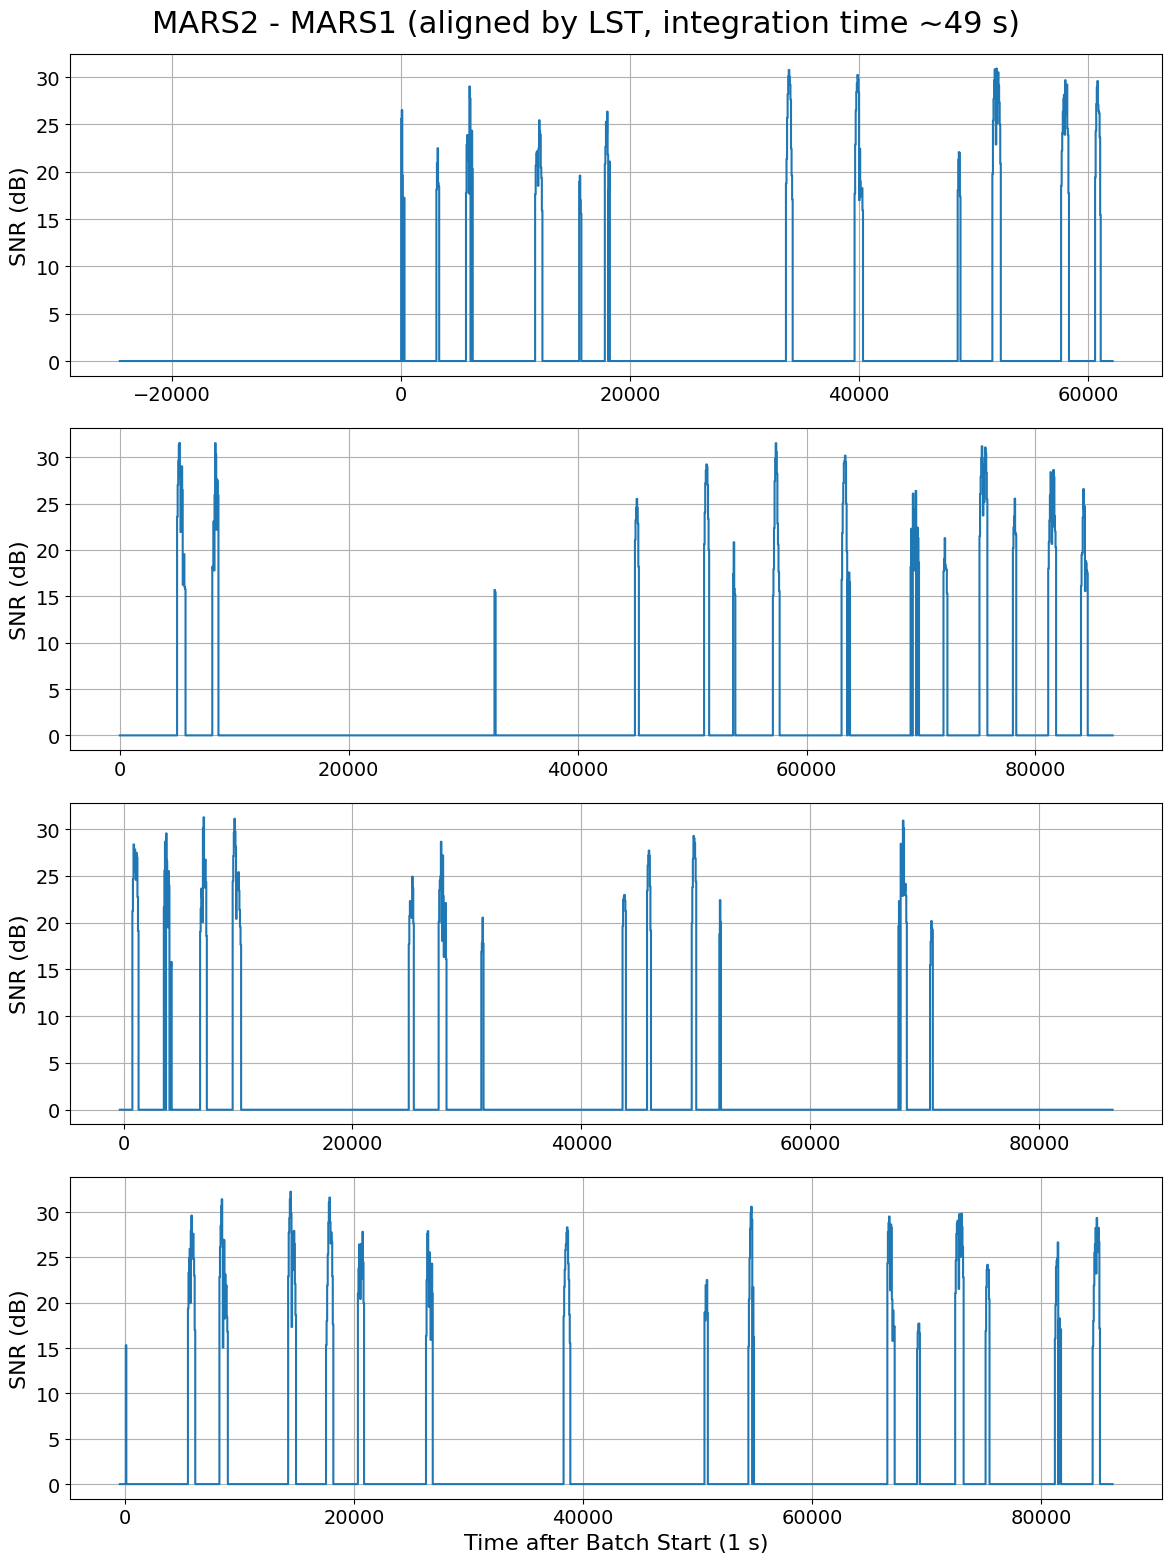

In [ ]:
#regular plot 
importlib.reload(su)
bsecs, btimes, fig = su.snr_times_many(
    [bpath1, bpath2, bpath3, bpath4], 
    [bstart1, bstart2, bstart3, bstart4], 
    [bend1, bend2, bend3, bend4], 
    ant_name)

fig.savefig('./images/nov25satdetmars1.png')

In [10]:
10*np.log10(1500)

31.760912590556813

## With mapping onto data presence

0
1762037640 1762099215
raw file ant 0 ['/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762037685.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762037739.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762037794.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762037846.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762037899.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762037954.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762038008.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762038062.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762038115.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762038169.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762038223.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/17620

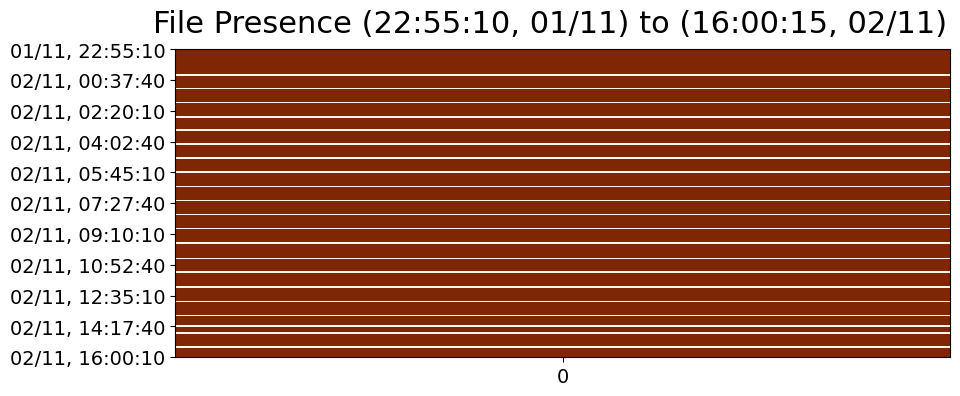

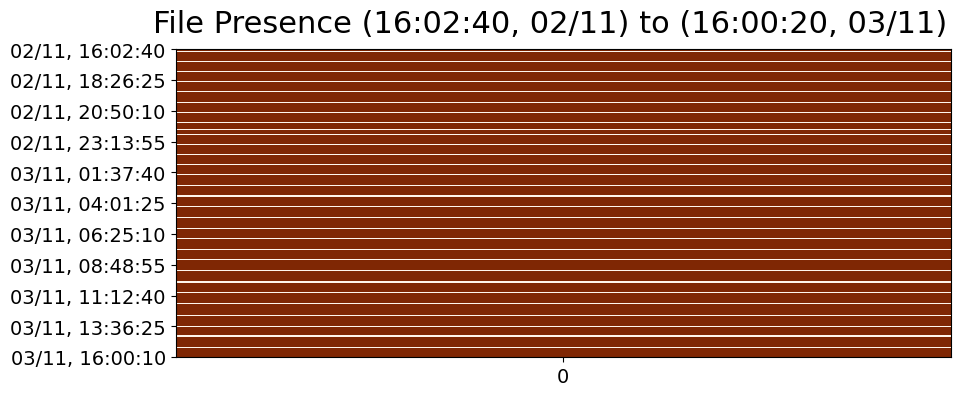

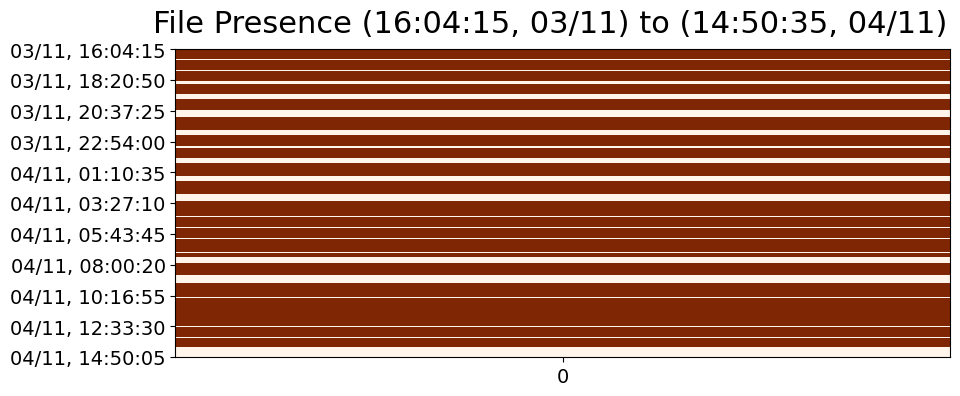

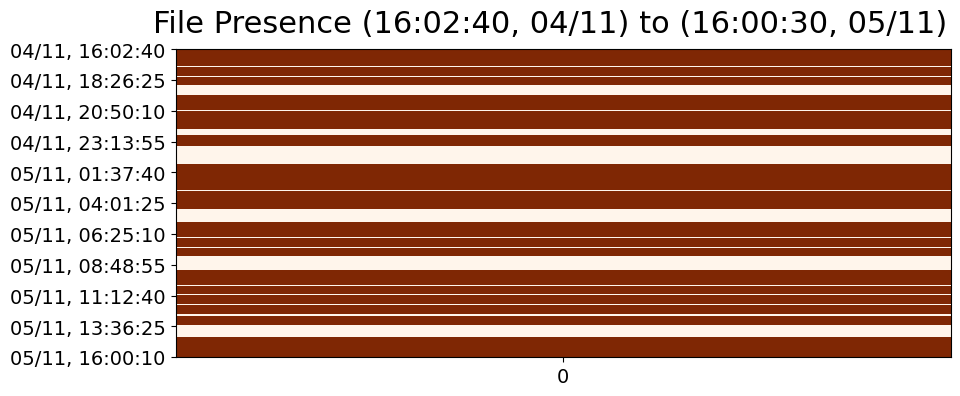

In [24]:
times_present = []
for i in range(4):
    arr, fig = butils.get_present_files(batch_starts[i], batch_ends[i], ['/project/rrg-sievers/albatros/mars/202507/mars1'], T_SCAN = 5)
    runs = butils.get_simul_files(arr, batch_starts[i], 5, [0])
    times_present.append(runs)

In [26]:
print(times_present[0][0])

[1762037710, 1762042680]


start lsts [294.502457230807, 192.08075457793896, 193.46331454480307, 194.05204073534233]
min lst 192.08075457793896
Front padding triggered at 24581
Front padding triggered at 331
Front padding triggered at 473
max array len 86744
pad 657
pad 483
pad 4432
pad 0


/home/thomasb/albatros_analysis/scripts/orbcomm/sat_utils.py:385: RuntimeWarning: divide by zero encountered in log10
  snr_db = np.where(snrarr > 0, 10 * np.log10(snrarr), 0.0)


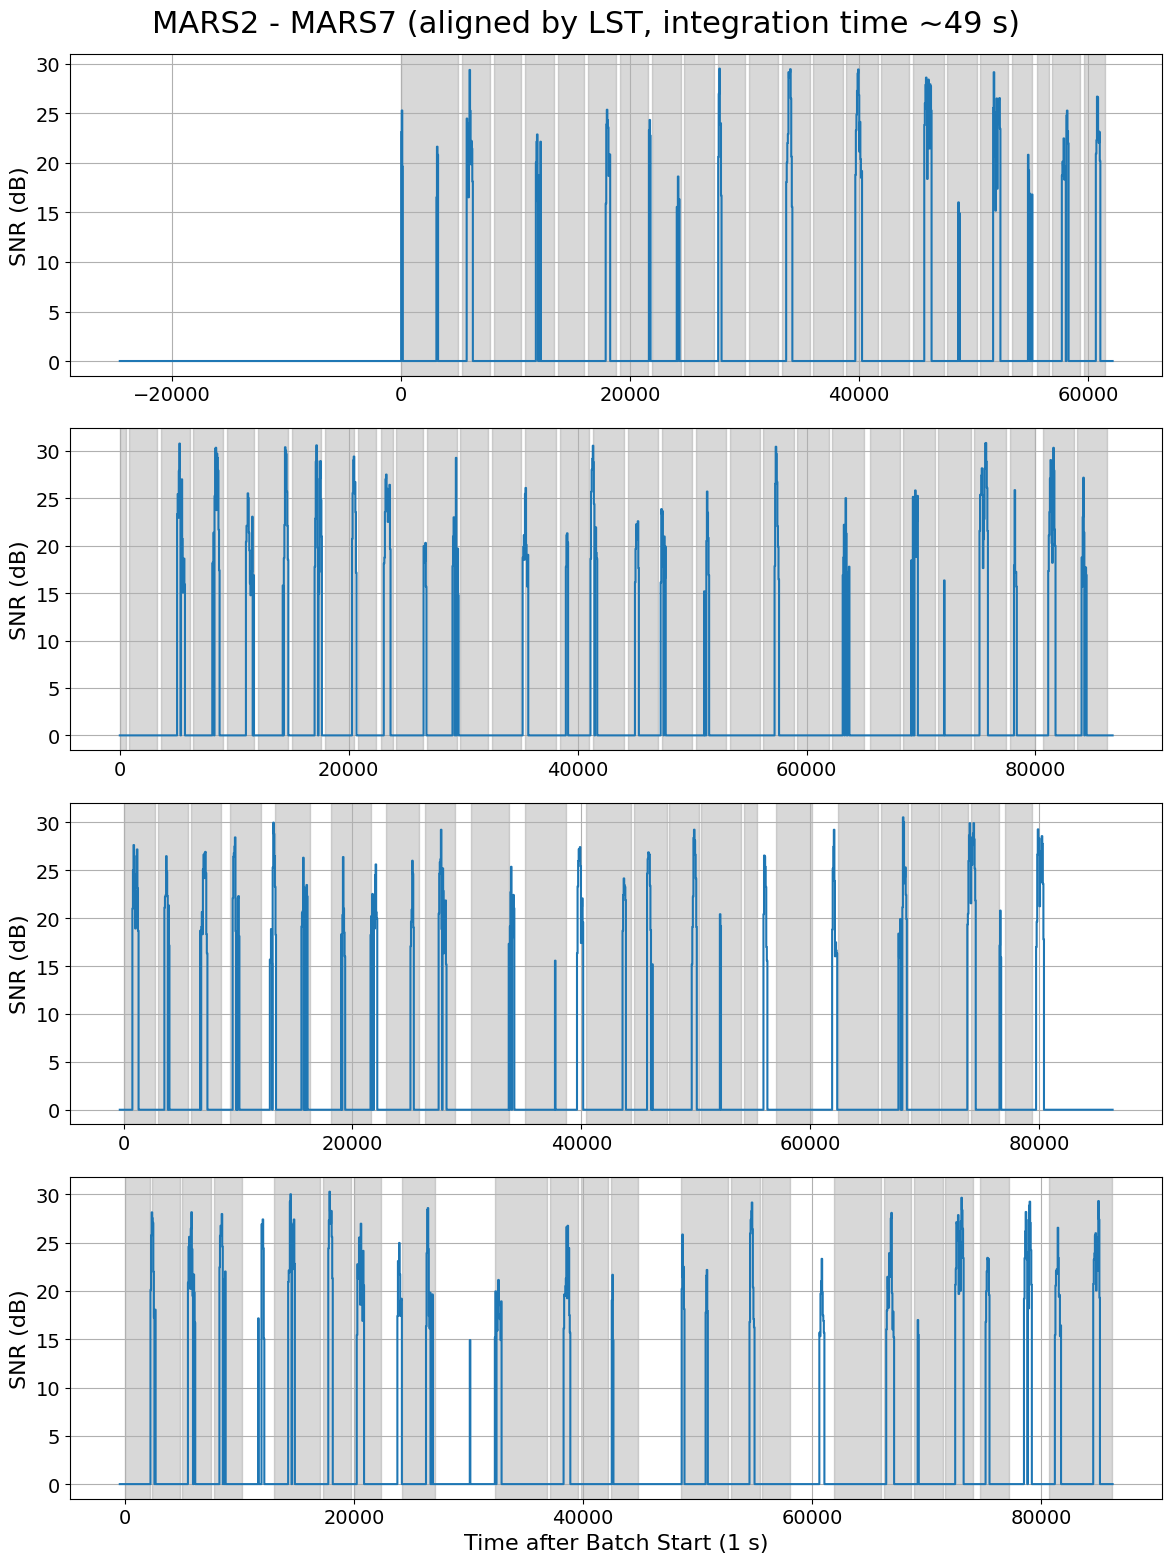

In [29]:
ref_antname = 'MARS2'
antname = 'MARS7'
dt=1
coords = [79.41717895, -90.76721818, 188.095]
T_SPECTRA = 4096/250e6
c_acclen = 3e6
json_paths = [bpath1, bpath2, bpath3, bpath4] 
batch_starts = [bstart1, bstart2, bstart3, bstart4]
batch_ends = [bend1, bend2, bend3, bend4]

#using coords of MARS 1 as a reference for LST
assert len(json_paths) == len(batch_starts)
assert len(json_paths) == len(batch_ends)
nbatches = len(json_paths)

secs, lsts, snrs = [], [], []
for i in range(nbatches):
    data = su.load_json(json_paths[i])[f'{antname}']
    secs.append(np.arange(0, batch_ends[i]-batch_starts[i] + 1, dt))
    lsts.append(su.unix_to_lst_with_fix(batch_starts[i], batch_ends[i], coords))
    snr  = np.zeros_like(secs[i], dtype=float)

    # extract pulse times (floats since chunked)
    for pulse in data:
        t0, t1 = pulse["times"]
        t0 -= batch_starts[i]
        t1 -= batch_starts[i]
        snr_vals = [x[0] for x in pulse["SNR, Chan, Sat"]]
        n = len(snr_vals)

        # get chunk boundaries (since SNR will change across them)
        boundaries = np.linspace(t0, t1, n + 1)

        for j, val in enumerate(snr_vals):
            # seconds covered by this SNR value
            mask = (secs[i] >= boundaries[j]) & (secs[i] < boundaries[j + 1])
            snr[mask] = val
    snrs.append(snr)

start_lsts = [float(lst[0]) for lst in lsts]
print('start lsts', start_lsts)
lst_min = min(start_lsts)
print('min lst', lst_min)

secs_raw = secs.copy()
snrs_raw = snrs.copy()

lst_to_sec = 240
aligned_secs = []
aligned_snrs = []

#padding at the start
for sec, snr, start_lst in zip(secs, snrs, start_lsts):
    shift_sec = int((start_lst - lst_min) * lst_to_sec)
    if shift_sec > 0:
        print(f'Front padding triggered at {shift_sec}')
        snr = np.pad(snr, (shift_sec, 0), constant_values=0)
        sec = np.concatenate([np.arange(-shift_sec, 0), sec])
    aligned_snrs.append(snr)
    aligned_secs.append(sec)

max_len = max(len(s) for s in aligned_snrs)
print('max array len', max_len)

for i in range(len(aligned_snrs)):
    pad = max_len - len(aligned_snrs[i])
    print('pad', pad)
    if pad > 0:
        aligned_snrs[i] = np.pad(
            aligned_snrs[i], (0, pad), constant_values=0
        )
        aligned_secs[i] = np.concatenate(
            [aligned_secs[i], np.arange(max(aligned_secs[i]), max(aligned_secs[i]) + pad)]
        )

fig, ax = plt.subplots(nbatches, 1, figsize=(12, 4 * nbatches))
plt.rcParams.update({
            "font.size": 16,
            "axes.labelsize": 16,
            "axes.titlesize": 20,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "figure.titlesize": 22,
            "figure.dpi": 100,
            "savefig.dpi": 300
        })
if nbatches == 1:
    ax = [ax]
fig.suptitle(f"{ref_antname} - {antname} (aligned by LST, integration time ~{int(c_acclen * T_SPECTRA)} s)")
for i in range(nbatches):
    ax[i].step(aligned_secs[i], su.snr2db(aligned_snrs[i]), where="post")
    ax[i].set_ylabel("SNR (dB)")
    ax[i].grid(True)
    for minibatch in times_present[i]:
        ax[i].axvspan(minibatch[0]-batch_starts[i], minibatch[1]-batch_starts[i],color='gray',alpha=0.3,zorder=0)

ax[nbatches-1].set_xlabel(f"Time after Batch Start ({int(dt)} s)")
plt.tight_layout()
fig.savefig('./images/nov25satdet.png')